## Bayesian Poisson mixed-effects model

We fit a Bayesian Poisson mixed-effects model:

$$\log \lambda_{ij} = \beta_{0} + \beta_{FUN} \times \text{condition}_{ij} + \alpha_i$$
$$\alpha_i \sim \mathcal{N}(0,\, \sigma_{player})$$

**Parameters:**
- $\lambda_{ij}$: expected tag count for player $i$, observation $j$
- $\beta_{0}$: log of the baseline tag rate (baseline (WIN) condition, average player)
- $\beta_{FUN}$: log of the FUN multiplier — $e^{\beta_{FUN}}$ is the IRR
- $\text{condition}_{ij}$: 0 for WIN, 1 for FUN
- $\alpha_i$: player-specific intercept — how much this player deviates from average, on the log scale
- $\sigma_{player}$: SD of the player-intercept distribution

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BG='#F8F5F0'; DARK='#1C1C2E'; MID='#5A5A7A'; GRID='#E2DDD6'
WIN='#648FFF'; FUN='#DC267F'
plt.rcParams.update({
    'figure.facecolor':BG, 'axes.facecolor':BG, 'axes.edgecolor':GRID,
    'axes.labelcolor':MID, 'xtick.color':MID, 'ytick.color':MID,
    'text.color':DARK, 'font.size':9, 'figure.dpi':110, 'savefig.dpi':150,
    'savefig.facecolor':BG,
})
def style_ax(ax, title=None):
    ax.set_facecolor(BG)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(GRID); ax.spines['bottom'].set_color(GRID)
    if title: ax.set_title(title, fontsize=10, fontweight='bold', color=DARK, pad=6)

rng = np.random.default_rng(42)

## Data

In [45]:
events = pd.read_csv('../data/pilot.csv')
child = events[events['age_group'] == 'child'].copy()
# add player id as a column from group + player_tagged
child['player_id'] = child['group'] + '_' + child['player_tagged'].astype(str)

# Tag counts per (group, condition, player_id)
pilot = (child.groupby(['group','condition','player_id'])
          .size()
          .reset_index(name='tags'))

#print all of "pilot"
print(pilot)

   group condition player_id  tags
0     C1       FUN      C1_1     4
1     C1       FUN      C1_2     5
2     C1       FUN      C1_3     5
3     C1       FUN      C1_4     3
4     C1       WIN      C1_1     2
5     C1       WIN      C1_2     5
6     C1       WIN      C1_3     5
7     C1       WIN      C1_4     4
8     C2       FUN      C2_1     3
9     C2       FUN      C2_2     3
10    C2       FUN      C2_3     3
11    C2       FUN      C2_4     3
12    C2       WIN      C2_1     4
13    C2       WIN      C2_2     5
14    C2       WIN      C2_3     4
15    C2       WIN      C2_4     5
16    C3       FUN      C3_1     5
17    C3       FUN      C3_2     5
18    C3       FUN      C3_3     4
19    C3       FUN      C3_4     5
20    C3       WIN      C3_1     5
21    C3       WIN      C3_2     3
22    C3       WIN      C3_3     4
23    C3       WIN      C3_4     4


## Empirical anchors

In [46]:
# Marginal mean tag rate (β_WIN)
overall_mean = pilot['tags'].mean()
log_overall_mean = np.log(overall_mean)

# By-condition means (β_FUN)
fun_mean = pilot[pilot['condition']=='FUN']['tags'].mean()
win_mean = pilot[pilot['condition']=='WIN']['tags'].mean()
empirical_irr = fun_mean / win_mean
log_irr = np.log(empirical_irr)

# Player-level variation on the log scale (σ_player)
# Mean tag rate per player (averaging over their 2 rounds)
player_means = pilot.groupby(['player_id'])['tags'].mean()
# log-transform (add 0.5 to handle zeros — Anscombe-style smoothing)
sd_player_logscale = np.log(player_means + 0.5).std()

print(f'Overall mean tag count per round:     {overall_mean:.2f}')
print(f'  → log(mean) β_WIN:            {log_overall_mean:.2f}')
print()
print(f'FUN mean: {fun_mean:.2f}   WIN mean: {win_mean:.2f}')
print(f'  → empirical IRR:                    {empirical_irr:.3f}')
print(f'  → log(IRR) anchors β_FUN:           {log_irr:+.3f}')
print()
print(f'Player mean across rounds:{player_means.mean():.2f}   SD across players: {player_means.std():.2f}')
print(f'SD of log player means σ_player: {sd_player_logscale:.2f}')

Overall mean tag count per round:     4.08
  → log(mean) β_WIN:            1.41

FUN mean: 4.00   WIN mean: 4.17
  → empirical IRR:                    0.960
  → log(IRR) anchors β_FUN:           -0.041

Player mean across rounds:4.08   SD across players: 0.67
SD of log player means σ_player: 0.15


## β_WIN  —  baseline log tag rate

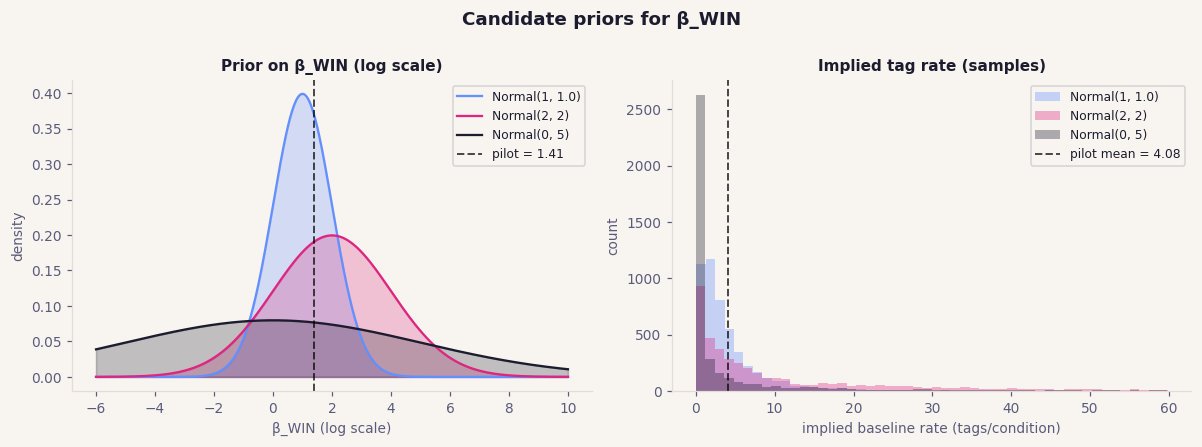

In [47]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
candidates_b0 = [
    ('Normal(1, 1.0)', 1.0, 1.0, WIN),
    ('Normal(2, 2)',   2.0, 2.0, FUN),
    ('Normal(0, 5)',   0.0, 5.0, DARK),
]
x_log = np.linspace(-6, 10, 500)
for label, mu, sigma, color in candidates_b0:
    pdf = stats.norm.pdf(x_log, mu, sigma)
    ax_l.fill_between(x_log, pdf, alpha=0.25, color=color)
    ax_l.plot(x_log, pdf, color=color, lw=1.5, label=label)
    samples = rng.normal(mu, sigma, 5000)
    display = np.exp(samples); display = display[display < 60]
    ax_r.hist(display, bins=50, color=color, alpha=0.35, edgecolor='none', label=label)

ax_l.axvline(log_overall_mean, color='black', lw=1.3, ls='--', alpha=0.7,
             label=f'pilot = {log_overall_mean:.2f}')
ax_r.axvline(overall_mean, color='black', lw=1.3, ls='--', alpha=0.7,
             label=f'pilot mean = {overall_mean:.2f}')
ax_l.set_xlabel('β_WIN (log scale)'); ax_l.set_ylabel('density')
ax_r.set_xlabel('implied baseline rate (tags/condition)'); ax_r.set_ylabel('count')
for ax in (ax_l, ax_r): ax.legend(fontsize=8)
style_ax(ax_l, title='Prior on β_WIN (log scale)')
style_ax(ax_r, title='Implied tag rate (samples)')
fig.suptitle('Candidate priors for β_WIN', fontsize=12, fontweight='bold', color=DARK, y=1.0)
fig.tight_layout(); plt.show()


## β_FUN  —  log-IRR (Normal: FUN ≥ WIN)

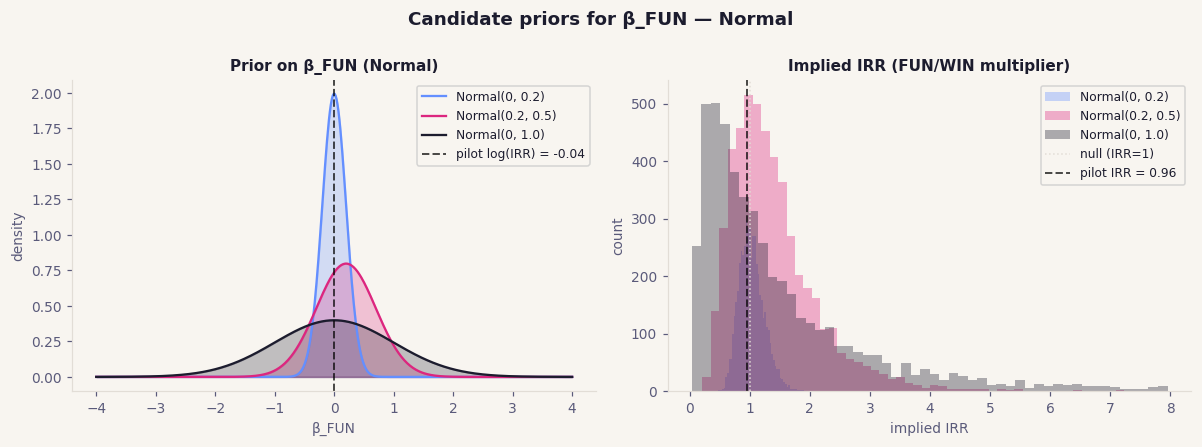

In [48]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
candidates_bfun = [
    ('Normal(0, 0.2)', 0, 0.2, WIN),
    ('Normal(0.2, 0.5)', 0.2, 0.5, FUN),
    ('Normal(0, 1.0)', 0, 1.0, DARK),
]
x_log = np.linspace(-4, 4, 500)
for label, mu, sigma, color in candidates_bfun:
    pdf = stats.norm.pdf(x_log, mu, sigma)
    ax_l.fill_between(x_log, pdf, alpha=0.25, color=color)
    ax_l.plot(x_log, pdf, color=color, lw=1.5, label=label)
    samples = rng.normal(mu, sigma, 5000)
    irrs = np.exp(samples); display = irrs[irrs < 8]
    ax_r.hist(display, bins=50, color=color, alpha=0.35, edgecolor='none', label=label)

ax_l.axvline(max(0, log_irr), color='black', lw=1.3, ls='--', alpha=0.7,
             label=f'pilot log(IRR) = {log_irr:+.2f}')
ax_r.axvline(1, color=GRID, lw=1, ls=':', label='null (IRR=1)')
ax_r.axvline(empirical_irr, color='black', lw=1.3, ls='--', alpha=0.7,
             label=f'pilot IRR = {empirical_irr:.2f}')
ax_l.set_xlabel('β_FUN'); ax_l.set_ylabel('density')
ax_r.set_xlabel('implied IRR'); ax_r.set_ylabel('count')
for ax in (ax_l, ax_r): ax.legend(fontsize=8)
style_ax(ax_l, title='Prior on β_FUN (Normal)')
style_ax(ax_r, title='Implied IRR (FUN/WIN multiplier)')
fig.suptitle('Candidate priors for β_FUN — Normal',
             fontsize=12, fontweight='bold', color=DARK, y=1.0)
fig.tight_layout(); plt.show()

## σ_player  —  player-level SD (log scale)

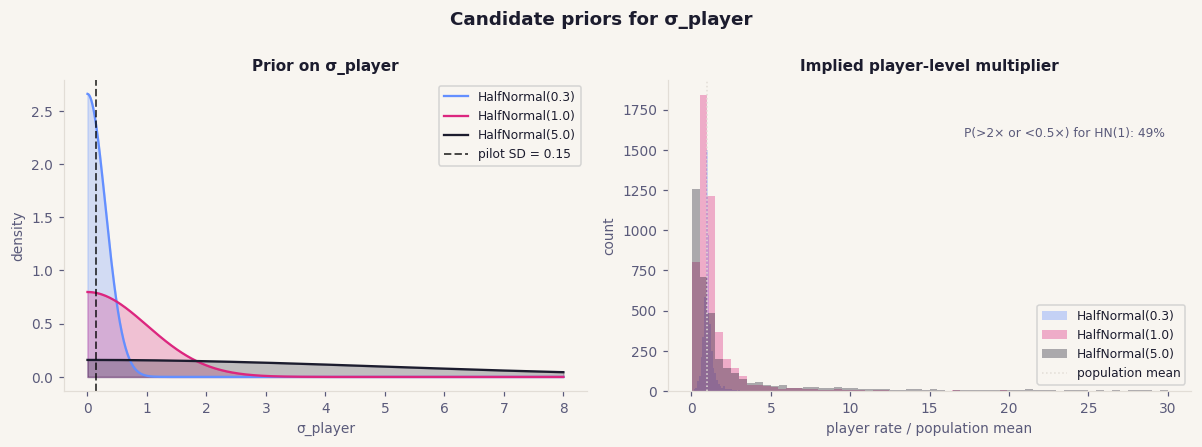

In [49]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
candidates_sig = [
    ('HalfNormal(0.3)', 0.3, WIN),
    ('HalfNormal(1.0)', 1.0, FUN),
    ('HalfNormal(5.0)', 5.0, DARK),
]
x_log = np.linspace(0, 8, 500)
for label, sigma, color in candidates_sig:
    pdf = 2 * stats.norm.pdf(x_log, 0, sigma)
    ax_l.fill_between(x_log, pdf, alpha=0.25, color=color)
    ax_l.plot(x_log, pdf, color=color, lw=1.5, label=label)
    sig_samples = np.abs(rng.normal(0, sigma, 5000))
    alpha_samples = rng.normal(0, sig_samples)
    multipliers = np.exp(alpha_samples)
    display = multipliers[(multipliers > 0.01) & (multipliers < 30)]
    ax_r.hist(display, bins=60, color=color, alpha=0.35, edgecolor='none', label=label)

ax_l.axvline(sd_player_logscale, color='black', lw=1.3, ls='--', alpha=0.7,
             label=f'pilot SD = {sd_player_logscale:.2f}')
ax_r.axvline(1, color=GRID, lw=1, ls=':', label='population mean')
p_2x = (np.exp(np.abs(rng.normal(0, 1.0, 50000))) > 2).mean() * 100
ax_r.text(0.95, 0.85, f'P(>2× or <0.5×) for HN(1): {p_2x:.0f}%',
          transform=ax_r.transAxes, ha='right', va='top', fontsize=8, color=MID)
ax_l.set_xlabel('σ_player'); ax_l.set_ylabel('density')
ax_r.set_xlabel('player rate / population mean'); ax_r.set_ylabel('count')
for ax in (ax_l, ax_r): ax.legend(fontsize=8)
style_ax(ax_l, title='Prior on σ_player')
style_ax(ax_r, title='Implied player-level multiplier')
fig.suptitle('Candidate priors for σ_player', fontsize=12, fontweight='bold', color=DARK, y=1.0)
fig.tight_layout(); plt.show()


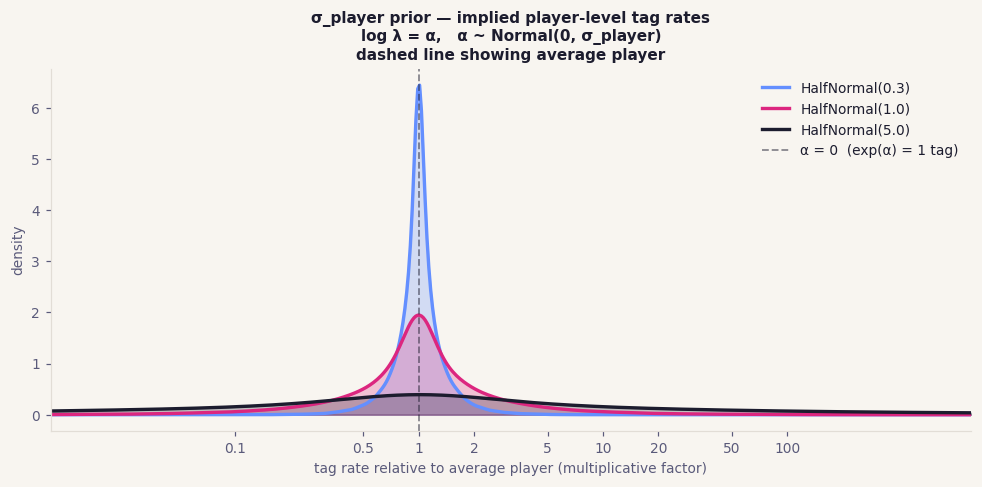

In [50]:
# ── σ_player prior: implied player-level tag rates ────────────────────────
# Simplified model: log λ = α,  α ~ Normal(0, σ),  σ ~ HalfNormal(scale)

L10 = np.log(10)

candidates = [
    ('HalfNormal(0.3)', 0.3, WIN),
    ('HalfNormal(1.0)', 1.0, FUN),
    ('HalfNormal(5.0)', 5.0, DARK),
]

fig, ax = plt.subplots(figsize=(9, 4.5))

for label, scale, color in candidates:
    sigma       = np.abs(rng.normal(0, scale, 100_000))
    alpha       = rng.normal(0, sigma)
    alpha_log10 = alpha / L10          # natural log → log10 for display
    kde = stats.gaussian_kde(alpha_log10, bw_method=0.15)
    xs  = np.linspace(-2, 3, 500)
    ax.fill_between(xs, kde(xs), alpha=0.25, color=color)
    ax.plot(xs, kde(xs), color=color, lw=2.2, label=label)

ax.axvline(0, color=DARK, lw=1.2, ls='--', alpha=0.5, label='α = 0  (exp(α) = 1 tag)')

tick_vals = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]
ax.set_xticks([np.log10(v) for v in tick_vals])
ax.set_xticklabels([str(v) for v in tick_vals])
ax.set_xlim(-2, 3)

ax.set_xlabel('tag rate relative to average player (multiplicative factor)')
ax.set_ylabel('density')
ax.legend(fontsize=9, frameon=False)
style_ax(ax, title='σ_player prior — implied player-level tag rates\n'
                    'log λ = α,   α ~ Normal(0, σ_player)\n'
                    'dashed line showing average player')
fig.tight_layout()
plt.show()

## Prior predictive check

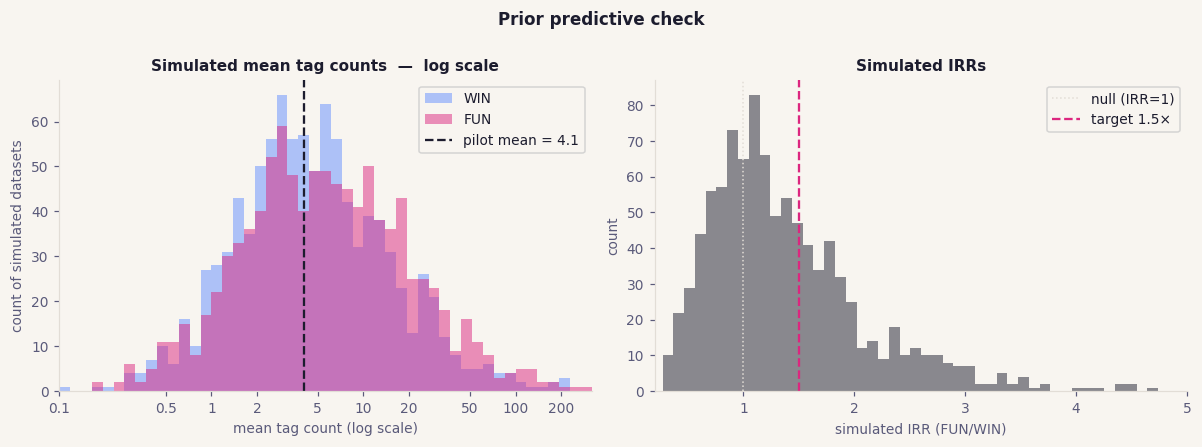

WIN  median=4.28,  5–95 % = [0.7, 33.4]
FUN  median=5.36,  5–95 % = [0.7, 50.1]
IRR  median=1.21,  5–95 % = [0.53, 2.80]


In [51]:
def prior_predictive(mu0, sig0, mu1, sig1, scale_sig,
                     n_players=40, n_obs_per_player=4, n_sims=1000, rng=None):
    """
    β_WIN    ~ Normal(mu0, sig0)
    β_FUN    ~ Normal(mu1, sig1)
    σ_player ~ HalfNormal(scale_sig)   always positive → SD is always ≥ 0
    """
    if rng is None: rng = np.random.default_rng()
    fun_means, win_means = [], []
    for _ in range(n_sims):
        b0         = rng.normal(mu0, sig0)
        b_fun      = rng.normal(mu1, sig1)    # Normal
        sig_player = np.abs(rng.normal(0, scale_sig))    # HalfNormal
        alphas     = rng.normal(0, sig_player, n_players)
        lam_win    = np.clip(b0 + alphas[:, None], -10, 10)
        lam_fun    = np.clip(b0 + b_fun + alphas[:, None], -10, 10)
        win_counts = rng.poisson(np.exp(lam_win), (n_players, n_obs_per_player // 2))
        fun_counts = rng.poisson(np.exp(lam_fun), (n_players, n_obs_per_player // 2))
        win_means.append(win_counts.mean())
        fun_means.append(fun_counts.mean())
    return np.array(fun_means), np.array(win_means)

fun_sim, win_sim = prior_predictive(
    mu0=1.0, sig0=1.0,      # β_WIN  ~ Normal(1, 1)
    mu1=0.2, sig1=0.5,       # β_FUN  ~ Normal(0, 0.5)
    scale_sig=1.0,          # σ      ~ HalfNormal(1)
    rng=rng,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: log x-axis so the log-normal distribution shows as a bell curve.
# Plotting on a linear axis squashes the distribution against zero and hides
# the bell shape — that is a display artefact, not a problem with the prior.
log10_win = np.log10(win_sim[win_sim > 0])
log10_fun = np.log10(fun_sim[fun_sim > 0])
bins = np.linspace(-1, 2.5, 50)
ax1.hist(log10_win, bins=bins, color=WIN, alpha=0.5, label='WIN', edgecolor='none')
ax1.hist(log10_fun, bins=bins, color=FUN, alpha=0.5, label='FUN', edgecolor='none')
ax1.axvline(np.log10(overall_mean), color=DARK, lw=1.5, ls='--',
            label=f'pilot mean = {overall_mean:.1f}')

# Relabel ticks as actual tag counts (not log values)
tick_vals = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
ax1.set_xticks([np.log10(v) for v in tick_vals])
ax1.set_xticklabels([str(v) for v in tick_vals])
ax1.set_xlim(-1, 2.5)
ax1.set_xlabel('mean tag count (log scale)'); ax1.set_ylabel('count of simulated datasets')
ax1.legend(fontsize=9)
style_ax(ax1, title='Simulated mean tag counts  —  log scale')

# Right: IRR always ≥ 1 due to HalfNormal prior on β_FUN
valid   = (win_sim > 0.5)
sim_irr = fun_sim[valid] / win_sim[valid]
ax2.hist(sim_irr, bins=50, color=DARK, alpha=0.5, edgecolor='none')
ax2.axvline(1,   color=GRID, lw=1,   ls=':', label='null (IRR=1)')
ax2.axvline(1.5, color=FUN,  lw=1.5, ls='--', label='target 1.5×')
ax2.set_xlim(0.2, 5); ax2.set_xlabel('simulated IRR (FUN/WIN)'); ax2.set_ylabel('count')
ax2.legend(fontsize=9)
style_ax(ax2, title='Simulated IRRs')

fig.suptitle('Prior predictive check', fontsize=11, fontweight='bold', color=DARK, y=1.0)
fig.tight_layout(); plt.show()

print(f'WIN  median={np.median(win_sim):.2f},  5–95 % = [{np.quantile(win_sim,.05):.1f}, {np.quantile(win_sim,.95):.1f}]')
print(f'FUN  median={np.median(fun_sim):.2f},  5–95 % = [{np.quantile(fun_sim,.05):.1f}, {np.quantile(fun_sim,.95):.1f}]')
print(f'IRR  median={np.median(sim_irr):.2f},  5–95 % = [{np.quantile(sim_irr,.05):.2f}, {np.quantile(sim_irr,.95):.2f}]')
